# Analytical and Numerical Methods for the Black-Scholes Equation in European Option Pricing

This notebook reproduces the numerical experiments used in the report. The finite difference methods solve the original Black-Scholes PDE in the time-to-maturity variable $\theta = T - t$. Crank-Nicolson is the main numerical method. Explicit Euler is imported as a simple educational method, but it is conditionally stable and is not used for the final results.

## A. Imports and configuration

In [1]:
from pathlib import Path
import sys

sys.dont_write_bytecode = True

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

from black_scholes_pde import (
    BlackScholesParams,
    GridParams,
    black_scholes_price,
    comparison_table,
    convergence_table,
    error_metrics,
    parameter_sensitivity,
    payoff,
    solve_crank_nicolson_fd,
    solve_explicit_fd,
)
from black_scholes_pde.visualization import (
    plot_convergence,
    plot_error,
    plot_parameter_sensitivity,
    plot_payoff_vs_exact,
    plot_price_comparison,
)

def save_figure(fig, filename):
    fig.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")

## B. Baseline parameters

The main example is a European call option with strike $K=100$, maturity $T=1$, interest rate $r=0.05$, volatility $\sigma=0.20$, and truncated asset domain $0 \leq s \leq 200$.

In [2]:
params = BlackScholesParams(
    strike=100,
    maturity=1,
    rate=0.05,
    volatility=0.20,
    option_type="call",
)
grid = GridParams(s_max=200, asset_steps=400, time_steps=400)
asset_grid = np.linspace(0.0, grid.s_max, grid.asset_steps + 1)
payoff_values = payoff(asset_grid, params.strike, params.option_type)
exact = black_scholes_price(asset_grid, params)

## C. Payoff vs exact Black-Scholes price

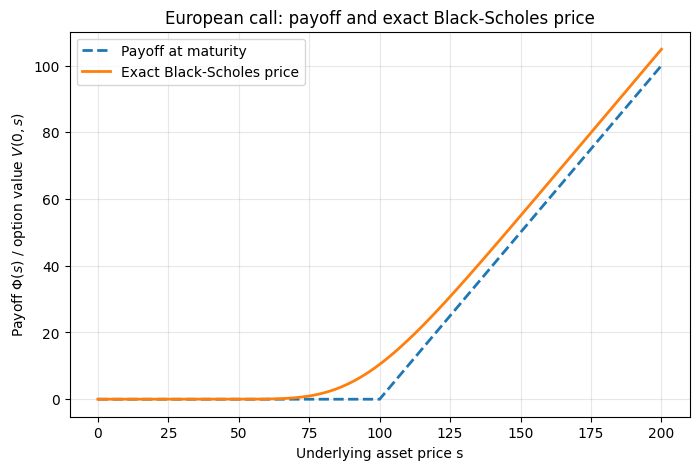

In [3]:
fig, ax = plot_payoff_vs_exact(
    asset_grid,
    exact,
    payoff_values,
    title="European call: payoff and exact Black-Scholes price",
)
save_figure(fig, "payoff_vs_exact_call.png")
plt.show()

## D. Crank-Nicolson solution

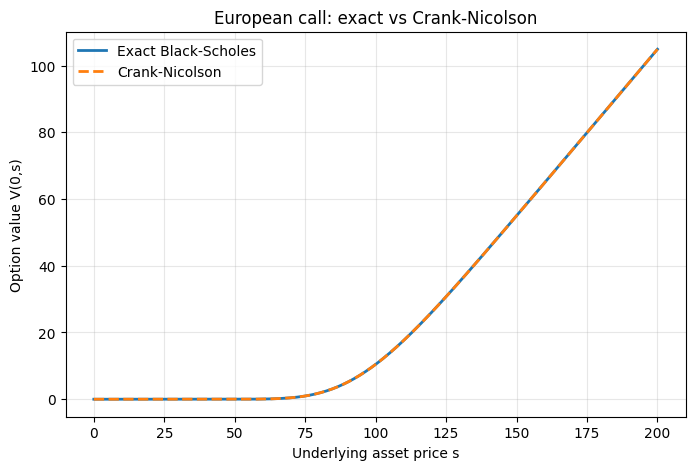

In [4]:
asset_grid, numerical = solve_crank_nicolson_fd(params, grid)
exact = black_scholes_price(asset_grid, params)

fig, ax = plot_price_comparison(
    asset_grid,
    numerical,
    exact,
    title="European call: exact vs Crank-Nicolson",
)
save_figure(fig, "exact_vs_crank_nicolson_call.png")
plt.show()

## E. Evolution of the finite difference solution

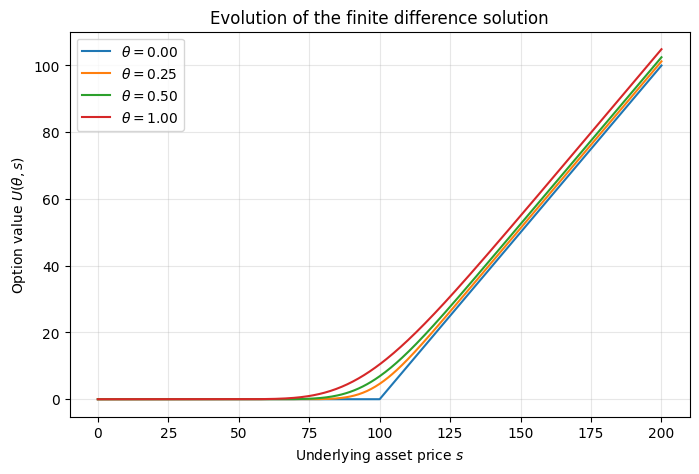

In [5]:
asset_grid, theta_grid, solution = solve_crank_nicolson_fd(
    params,
    grid,
    return_full_grid=True
)

fig, ax = plt.subplots(figsize=(8, 5))

for theta_value in [0.0, 0.25, 0.5, 1.0]:
    idx = np.argmin(np.abs(theta_grid - theta_value))
    ax.plot(asset_grid, solution[idx], label=f"$\\theta={theta_grid[idx]:.2f}$")

ax.set_xlabel("Underlying asset price $s$")
ax.set_ylabel("Option value $U(\\theta,s)$")
ax.set_title("Evolution of the finite difference solution")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "pde_solution_evolution_call.png")
plt.show()

## F. Absolute error plot

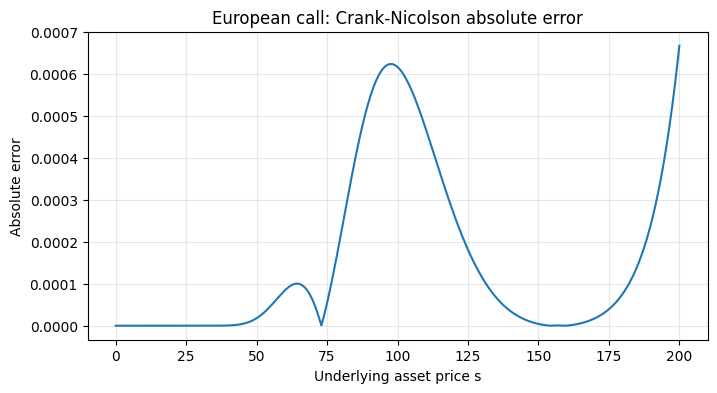

In [6]:
fig, ax = plot_error(
    asset_grid,
    numerical,
    exact,
    title="European call: Crank-Nicolson absolute error",
)
save_figure(fig, "absolute_error_call.png")
plt.show()

## F. Error metrics

In [7]:
call_error_metrics = error_metrics(numerical, exact)
call_error_metrics

{'max_abs_error': 0.000666684395113748,
 'mae': 0.0001520948982953899,
 'rmse': 0.0002513981329341812}

## G. Comparison table for selected asset prices

In [8]:
selected_prices = comparison_table([80, 100, 120], params, grid)
selected_prices

,asset_price,exact_price,numerical_price,absolute_error
0,80.0,1.859420,1.859199,0.000221
1,100.0,10.450584,10.449968,0.000616
2,120.0,26.169044,26.168778,0.000266


## H. Grid convergence analysis

In [9]:
convergence = convergence_table(
    params,
    grid_sizes=[(50, 50), (100, 100), (200, 200), (400, 400)],
    s_max=200,
)
convergence

,asset_steps,time_steps,max_abs_error,mae,rmse
0,50,50,0.039918,0.007632,0.014458
1,100,100,0.009985,0.001947,0.003625
2,200,200,0.002493,0.000512,0.000914
3,400,400,0.000667,0.000152,0.000251


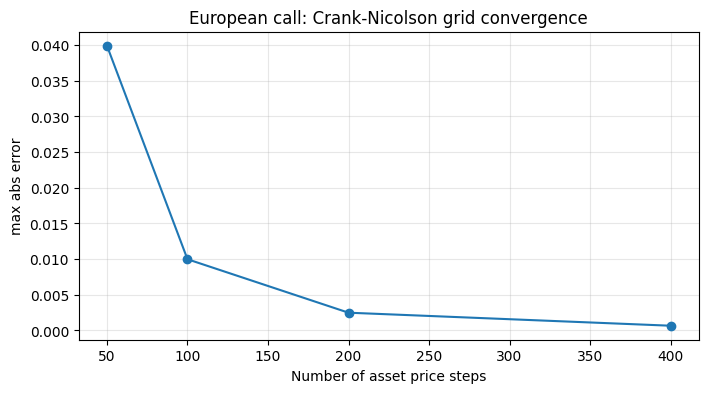

In [10]:
fig, ax = plot_convergence(
    convergence,
    metric="max_abs_error",
    title="European call: Crank-Nicolson grid convergence",
)
save_figure(fig, "grid_convergence_call.png")
plt.show()

## I. Parameter sensitivity analysis

The following plots use the exact Black-Scholes formula so each parameter effect is shown without numerical discretization error.

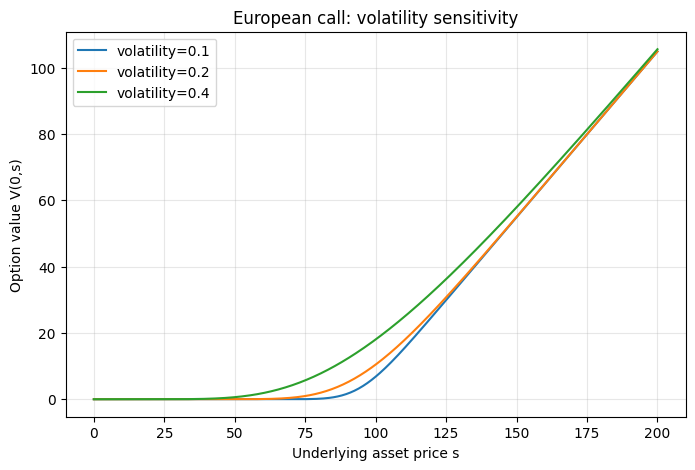

In [11]:
sensitivity_asset_grid = np.linspace(0.0, grid.s_max, grid.asset_steps + 1)

volatility_curves = parameter_sensitivity(
    sensitivity_asset_grid, params, "volatility", [0.10, 0.20, 0.40]
)
fig, ax = plot_parameter_sensitivity(
    sensitivity_asset_grid, volatility_curves, "volatility",
    title="European call: volatility sensitivity",
)
save_figure(fig, "volatility_sensitivity_call.png")
plt.show()

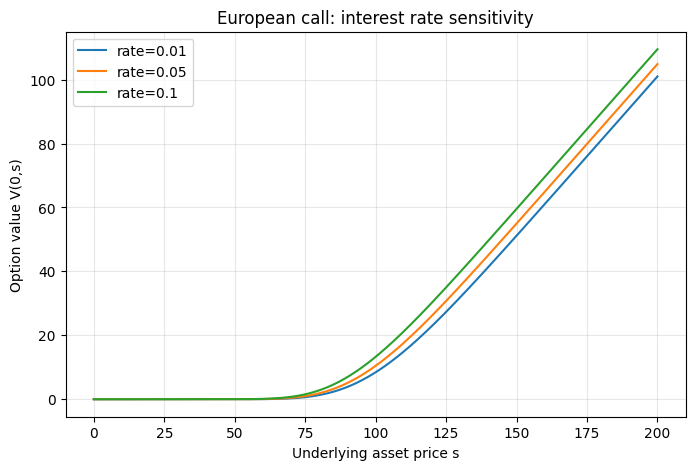

In [12]:
rate_curves = parameter_sensitivity(
    sensitivity_asset_grid, params, "rate", [0.01, 0.05, 0.10]
)
fig, ax = plot_parameter_sensitivity(
    sensitivity_asset_grid, rate_curves, "interest rate",
    title="European call: interest rate sensitivity",
)
save_figure(fig, "rate_sensitivity_call.png")
plt.show()

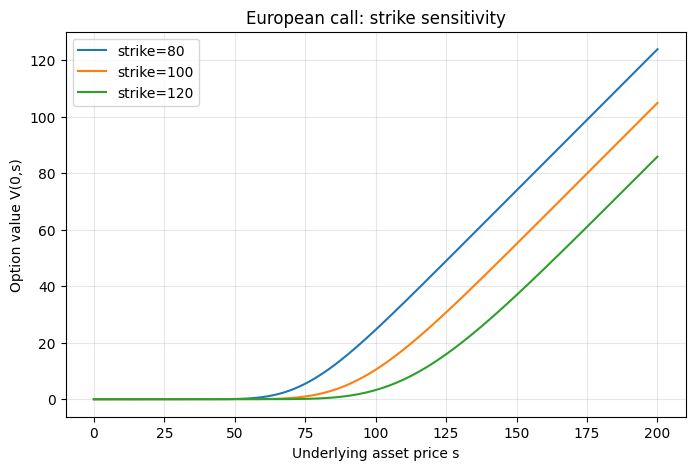

In [13]:
strike_curves = parameter_sensitivity(
    sensitivity_asset_grid, params, "strike", [80, 100, 120]
)
fig, ax = plot_parameter_sensitivity(
    sensitivity_asset_grid, strike_curves, "strike",
    title="European call: strike sensitivity",
)
save_figure(fig, "strike_sensitivity_call.png")
plt.show()

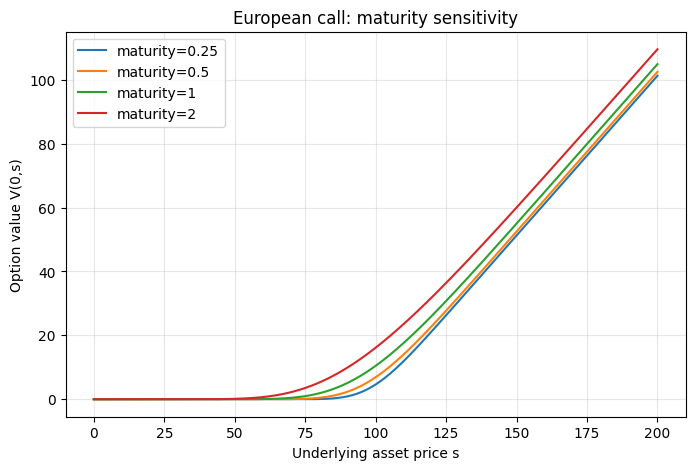

In [14]:
maturity_curves = parameter_sensitivity(
    sensitivity_asset_grid, params, "maturity", [0.25, 0.5, 1.0, 2.0]
)
fig, ax = plot_parameter_sensitivity(
    sensitivity_asset_grid, maturity_curves, "maturity",
    title="European call: maturity sensitivity",
)
save_figure(fig, "maturity_sensitivity_call.png")
plt.show()

## J. Optional European put example

{'max_abs_error': 0.0006666843951132276,
 'mae': 0.00015209754553620285,
 'rmse': 0.0002514009024523097}

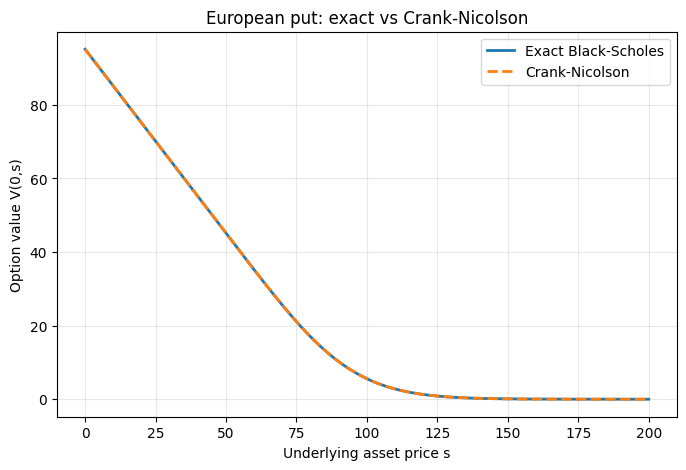

In [15]:
put_params = BlackScholesParams(
    strike=100,
    maturity=1,
    rate=0.05,
    volatility=0.20,
    option_type="put",
)
put_asset_grid, put_numerical = solve_crank_nicolson_fd(put_params, grid)
put_exact = black_scholes_price(put_asset_grid, put_params)

fig, ax = plot_price_comparison(
    put_asset_grid,
    put_numerical,
    put_exact,
    title="European put: exact vs Crank-Nicolson",
)
put_error_metrics = error_metrics(put_numerical, put_exact)
put_error_metrics